In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import glob
from time import time

from RaTag.core.datatypes import Run, SetPmt
from RaTag.core.config import TimingConfig, IntegrationConfig, FitConfig

from RaTag.io.bootstrap import bootstrap_from_config
from RaTag.alphas.alphas_workflow import map_alpha_events
from RaTag.alphas.alphas_calibration import map_alpha_calibrations, map_alpha_plots

# Initialize test run and set

In [7]:
# raw_data_path = '/Users/pabloherrero/sabat/RaTagging/test_data/raw_data/RUN8/'
# raw_data_path = "/Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN8_EL2350Vcm_5GSsec"
# config_path = '/Users/pabloherrero/sabat/RaTagging/test_data/configs/run8_analysis.yaml'
# config_path = '/Users/pabloherrero/sabat/RaTagging/configs/recoils/run8_analysis.yaml'
config_path = '/Users/pabloherrero/sabat/RaTagging/configs/recoils/run36_analysis.yaml'
# config_path = '/Users/pabloherrero/sabat/RaTagging/configs/recoils/run18_analysis.yaml'  # Multi-isotope run with 3 alpha sets!

run = bootstrap_from_config(config_path)

Found 10 directories in RUN36_EL25kVcm
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0120_Anode1120 with 20 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0156_Anode1156 with 20 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0188_Anode1188 with 20 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0216_Anode1216 with 20 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0288_Anode1288 with 20 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0384_Anode1384 with 20 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0480_Anode1480 with 20 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0672_Anode1672 with 20 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0768_Anode1768 with 20 waveforms.
  → Bootstrapped 9 PMT Sets and 9 Alpha Sets. (Multi-Isotope: True)


# Compute Alpha Energies

In [8]:
runa = map_alpha_events(run, force=True)


RECONSTRUCTING ALPHA ENERGIES: RUN_36
  🔹 Resolving alpha energies for: FieldScan_Gate0120_Anode1120
  Iterating FieldScan_Gate0120_Anode1120: 20/20 (100.0%) | ETA: 00:00   
  ✓ FieldScan_Gate0120_Anode1120: Computed 'n_alpha_energies' and stored metadata
  🔹 Resolving alpha energies for: FieldScan_Gate0156_Anode1156
  Iterating FieldScan_Gate0156_Anode1156: 20/20 (100.0%) | ETA: 00:00   
  ✓ FieldScan_Gate0156_Anode1156: Computed 'n_alpha_energies' and stored metadata
  🔹 Resolving alpha energies for: FieldScan_Gate0188_Anode1188
  Iterating FieldScan_Gate0188_Anode1188: 20/20 (100.0%) | ETA: 00:00   
  ✓ FieldScan_Gate0188_Anode1188: Computed 'n_alpha_energies' and stored metadata
  🔹 Resolving alpha energies for: FieldScan_Gate0216_Anode1216
  Iterating FieldScan_Gate0216_Anode1216: 20/20 (100.0%) | ETA: 00:00   
  ✓ FieldScan_Gate0216_Anode1216: Computed 'n_alpha_energies' and stored metadata
  🔹 Resolving alpha energies for: FieldScan_Gate0288_Anode1288
  Iterating FieldScan_Gate

# Perform alpha fit and calibration

In [6]:
runc = map_alpha_calibrations(runa, force=False)
_ = map_alpha_plots(runc, force=True)


CALIBRATING ALPHA ENERGIES: RUN_35
  Calibrating alpha spectrum for FieldScan_Gate0120_Anode0920...
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/alpha_energies/FieldScan_Gate0120_Anode0920_alpha_energies.npz
    ✓ Bayesian overlap resolved at 4.475 mV
    ✓ Calibration successful. Mean Resolution: 2.99%
  ✓ FieldScan_Gate0120_Anode0920: Computed 'calib_a' and stored metadata
  Calibrating alpha spectrum for FieldScan_Gate0156_Anode0956...
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/alpha_energies/FieldScan_Gate0156_Anode0956_alpha_energies.npz
    ✓ Bayesian overlap resolved at 4.441 mV
    ✓ Calibration successful. Mean Resolution: 2.70%
  ✓ FieldScan_Gate0156_Anode0956: Computed 'calib_a' and stored metadata
  Calibrating alpha spectrum for FieldScan_Gate0188_Anode0988...
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/alpha_energies/FieldScan_Ga

# Debug single set

In [11]:
from RaTag.io import file_ops
from RaTag.alphas.alphas_plotting import plot_calibration_summary
from RaTag.alphas.alphas_calibration import _load_alpha_fits
from RaTag.core.config import ALPHA_PEAK_DEFINITIONS

In [5]:
set_alpha = runa.alpha_sets[0]
set_alpha

SetAlpha state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN34_EL15k/FieldScan_Gate0120_Anode0720
  filenames = <50 files, 47200 waveforms, FastFrame(944 frames/file)>
  multiiso = True
  ff = True
  nframes = 944
  gate = 120
  anode = 720
  n_alpha_energies = 49350
  calib_a = -0.08
  calib_b = 2.129
  calib_c = -2.321
  calib_order = 2
  mean_energy_resolution = 0.027
  isotope_ranges_V = {'Th228': [4.284, 4.391], 'Ra224': [4.511, 4.617], 'Bi212': [4.83, 4.979], 'Rn220': [5.027, 5.117], 'Po216': [5.414, 5.503], 'Po212': [7.062, 7.217]}
  isotope_ranges_E = {'Th228': [5.325, 5.478], 'Ra224': [5.647, 5.796], 'Bi212': [6.088, 6.288], 'Rn220': [6.351, 6.47], 'Po216': [6.851, 6.962], 'Po212': [8.709, 8.862]}

  Missing:
    sampling_rate

In [14]:
arrays = file_ops.load_npz_arrays(set_alpha, 'alpha_energies')
energies_SCA = arrays['energies']

fit_results = _load_alpha_fits(set_alpha)
fit_results

{'Th228': <lmfit.model.ModelResult at 0x1305f6220>,
 'Ra224': <lmfit.model.ModelResult at 0x13032db50>,
 'Bi212': <lmfit.model.ModelResult at 0x130622e50>,
 'Rn220': <lmfit.model.ModelResult at 0x130434fa0>,
 'Po216': <lmfit.model.ModelResult at 0x1304578b0>,
 'Po212': <lmfit.model.ModelResult at 0x130434e80>}

In [18]:
set_alpha.isotope_ranges_V['Th228']

[4.284, 4.391]

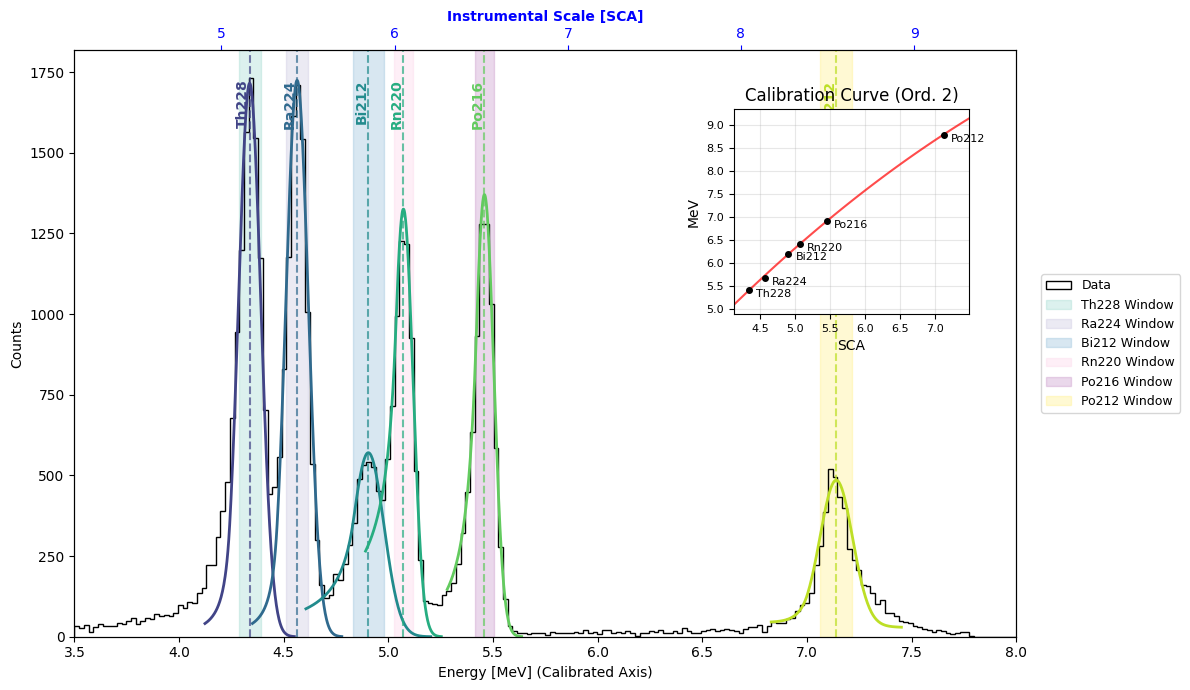

In [26]:
fig_summary = plot_calibration_summary(
        energies_SCA=energies_SCA,
        fit_results=fit_results,
        calib_coeffs=(set_alpha.calib_a, set_alpha.calib_b, set_alpha.calib_c),
        ranges_V=set_alpha.isotope_ranges_V,
        peak_definitions=ALPHA_PEAK_DEFINITIONS
)